# Problem 1 Clean Flow Guide

This notebook is arranged as a story:

1. Define the exact volumes.
2. Use bounding-box Monte Carlo as the baseline estimator.
3. Verify it works for 2D and 3D.
4. Show why bounding-box choice matters.
5. Show why the same method fails at n = 100.
6. Explain the failure with the curse of dimensionality.
7. Use recursive slicing and log-volume as the selected high-dimensional calculation improvement.
8. Use repeated Monte Carlo as a diagnostic.
9. Use direct radial sampling only as a sampling/geometry support method, not as the main volume estimator.

# MATH4010 Final Project — Problem 1
## Geometry and Monte Carlo Volume Estimation

We study two families of $n$-dimensional balls:

$$A_n = \left\{x \in \mathbb{R}^n : \left\|x - \tfrac{1}{2}\mathbf{1}\right\|_2 \leq \tfrac{1}{2}\right\} \quad\text{(ball of radius }\tfrac{1}{2}\text{ inscribed in }[0,1]^n)$$

$$B_n = \left\{x \in \mathbb{R}^n : \|x\|_2 \leq 1\right\} \quad\text{(unit ball at the origin)}$$

**Exact volume formula for an $n$-ball of radius $r$:**
$$V_n(r) = \frac{\pi^{n/2}}{\Gamma(n/2+1)}\,r^n$$

So:
$$\operatorname{Vol}(B_n) = \frac{\pi^{n/2}}{\Gamma(n/2+1)}, \qquad \operatorname{Vol}(A_n) = \frac{1}{2^n}\operatorname{Vol}(B_n)$$

In [1]:
import math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaln
from scipy.integrate import quad
from scipy.stats import qmc

warnings.filterwarnings("ignore")
SEED = 4010
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})
print("Setup complete. SEED =", SEED)

Setup complete. SEED = 4010


---
## Core library

All functions are defined once here. Every experiment below just calls them — no duplicated code.

In [2]:
# ── Exact volumes (log-scale to handle n=100 without underflow) ───────────────

def log_vol_B(n: int) -> float:
    """log Vol(B_n) = (n/2) log π − log Γ(n/2 + 1)"""
    return (n / 2) * math.log(math.pi) - gammaln(n / 2 + 1)

def log_vol_A(n: int) -> float:
    """log Vol(A_n) = log Vol(B_n) − n log 2"""
    return log_vol_B(n) - n * math.log(2)

def exact_vol(shape: str, n: int) -> float:
    """Exact volume; returns 0.0 for extreme underflow."""
    lv = log_vol_A(n) if shape == "A" else log_vol_B(n)
    return math.exp(lv) if lv > -745 else 0.0


# ── Membership tests ─────────────────────────────────────────────────────────

def in_A(x: np.ndarray) -> np.ndarray:
    """Boolean mask: is each row of x inside A_n?"""
    return np.sum((x - 0.5) ** 2, axis=1) <= 0.25

def in_B(x: np.ndarray) -> np.ndarray:
    """Boolean mask: is each row of x inside B_n?"""
    return np.sum(x ** 2, axis=1) <= 1.0


# ── Bounding-box Monte Carlo ──────────────────────────────────────────────────

def monte_carlo(shape: str, n: int, N: int = 100_000,
                seed: int = SEED, chunk: int = 50_000) -> dict:
    """
    Bounding-box hit-or-miss Monte Carlo.

    A_n: sample from [0,1]^n,  box_vol = 1.
    B_n: sample from [−1,1]^n, box_vol = 2^n.

    Returns a dict with shape, n, N, hits, hit_rate, estimate,
    exact, abs_error, rel_error, runtime.
    """
    rng = np.random.default_rng(seed)
    hits, done = 0, 0
    t0 = time.perf_counter()

    while done < N:
        m = min(chunk, N - done)
        if shape == "A":
            x = rng.uniform(0, 1, (m, n))
            hits += int(in_A(x).sum())
            log_box = 0.0
        else:
            x = rng.uniform(-1, 1, (m, n))
            hits += int(in_B(x).sum())
            log_box = n * math.log(2)
        done += m

    runtime = time.perf_counter() - t0
    hit_rate = hits / N
    log_est  = (log_box + math.log(hit_rate)) if hit_rate > 0 else -math.inf
    estimate = math.exp(log_est) if log_est > -745 else 0.0
    exact    = exact_vol(shape, n)

    return dict(
        shape=shape, n=n, N=N,
        hits=hits, hit_rate=hit_rate,
        estimate=estimate, exact=exact,
        abs_error=abs(estimate - exact),
        rel_error=(abs(estimate - exact) / exact) if exact > 0 else float("nan"),
        runtime=runtime,
    )


# ── Repeated Monte Carlo ──────────────────────────────────────────────────────

def repeated_mc(shape: str, n: int, N: int = 10_000,
                repeats: int = 30, seed: int = SEED) -> dict:
    """
    Run monte_carlo `repeats` times and summarise variability.
    Returns mean, std, 95% CI half-width, zero-hit fraction.
    """
    estimates = [monte_carlo(shape, n, N, seed=seed + k)["estimate"]
                 for k in range(repeats)]
    arr = np.array(estimates)
    return dict(
        shape=shape, n=n, N=N, repeats=repeats,
        mean=arr.mean(), std=arr.std(ddof=1),
        ci95=1.96 * arr.std(ddof=1) / math.sqrt(repeats),
        zero_hit_frac=(arr == 0).mean(),
    )


# ── Sobol quasi-Monte Carlo ───────────────────────────────────────────────────

def quasi_mc(shape: str, n: int, m: int = 13, seed: int = SEED) -> dict:
    """
    Sobol sequence quasi-Monte Carlo (N = 2^m points).
    Same bounding-box logic as monte_carlo.
    """
    N = 2 ** m
    sampler = qmc.Sobol(d=n, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)          # uniform on [0,1]^n

    if shape == "A":
        mask = in_A(u)
        estimate = mask.mean()
    else:
        x = 2 * u - 1
        mask = in_B(x)
        estimate = (2 ** n) * mask.mean()

    exact = exact_vol(shape, n)
    return dict(
        shape=shape, n=n, N=N,
        hits=int(mask.sum()), estimate=estimate, exact=exact,
        abs_error=abs(estimate - exact),
        rel_error=(abs(estimate - exact) / exact) if exact > 0 else float("nan"),
    )


# ── Convenience: run across many N values ─────────────────────────────────────

def sweep_N(shape: str, n: int,
            N_list=(100, 1_000, 10_000, 100_000),
            seed: int = SEED) -> pd.DataFrame:
    """Run monte_carlo for every N in N_list and return a tidy DataFrame."""
    return pd.DataFrame([monte_carlo(shape, n, N, seed=seed + N) for N in N_list])


# ── Convenience: compute exact table across dimensions ────────────────────────

def exact_table(dims=(1,2,3,5,10,20,50,100)) -> pd.DataFrame:
    """Return log/exact volumes of A_n and B_n for each dimension."""
    rows = []
    for n in dims:
        lA, lB = log_vol_A(n), log_vol_B(n)
        rows.append(dict(
            n=n,
            log_vol_A=lA, log_vol_B=lB,
            vol_A=math.exp(lA) if lA > -745 else 0.0,
            vol_B=math.exp(lB) if lB > -745 else 0.0,
            log_hit_rate_A=lA,                  # box for A is [0,1]^n, vol=1
            log_hit_rate_B=lB - n*math.log(2),  # box for B is [-1,1]^n, vol=2^n
        ))
    return pd.DataFrame(rows)


print("Core library ready.")
print("Quick sanity check:")
print(f"  Vol(A2) = {exact_vol('A',2):.6f}  (expected π/4  ≈ {math.pi/4:.6f})")
print(f"  Vol(B2) = {exact_vol('B',2):.6f}  (expected π    ≈ {math.pi:.6f})")
print(f"  Vol(A3) = {exact_vol('A',3):.6f}  (expected π/6  ≈ {math.pi/6:.6f})")
print(f"  Vol(B3) = {exact_vol('B',3):.6f}  (expected 4π/3 ≈ {4*math.pi/3:.6f})")

Core library ready.
Quick sanity check:
  Vol(A2) = 0.785398  (expected π/4  ≈ 0.785398)
  Vol(B2) = 3.141593  (expected π    ≈ 3.141593)
  Vol(A3) = 0.523599  (expected π/6  ≈ 0.523599)
  Vol(B3) = 4.188790  (expected 4π/3 ≈ 4.188790)


---
## Part 1.a — $A_2$ and $B_2$ (2-D)

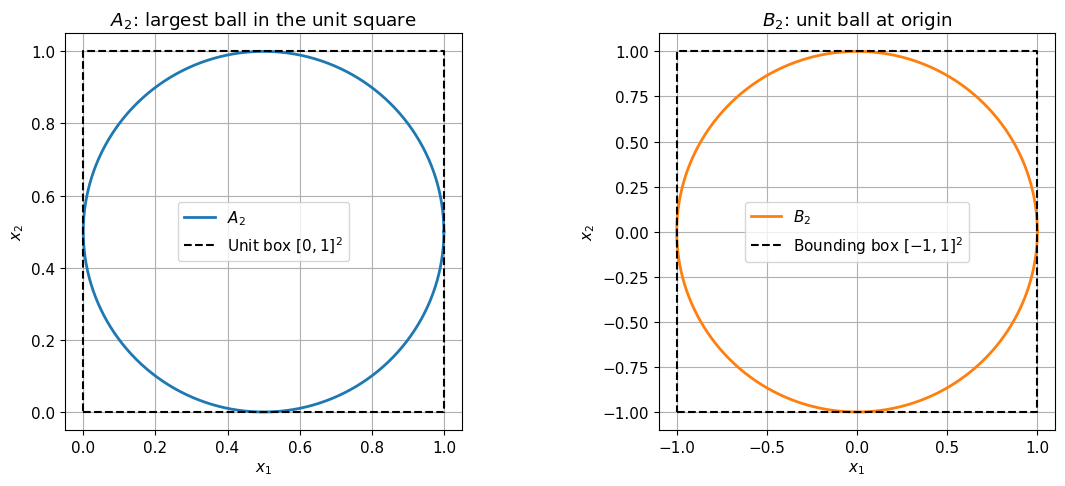

Exact area  A2 = π/4  = 0.785398
Exact area  B2 = π    = 3.141593


In [3]:
# ── Visualise ──────────────────────────────────────────────────────────────────
theta = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(0.5 + 0.5*np.cos(theta), 0.5 + 0.5*np.sin(theta), lw=2, label="$A_2$")
ax.plot([0,1,1,0,0], [0,0,1,1,0], "k--", label="Unit box $[0,1]^2$")
ax.set(title="$A_2$: largest ball in the unit square",
       xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend()

ax = axes[1]
ax.plot(np.cos(theta), np.sin(theta), lw=2, color="C1", label="$B_2$")
ax.plot([-1,1,1,-1,-1], [-1,-1,1,1,-1], "k--", label="Bounding box $[-1,1]^2$")
ax.set(title="$B_2$: unit ball at origin",
       xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Exact area  A2 = π/4  = {exact_vol('A',2):.6f}")
print(f"Exact area  B2 = π    = {exact_vol('B',2):.6f}")

We run Monte Carlo to estimate volume of A2 and B2 first:

In [ ]:
# ── Monte Carlo convergence across N on A2, B2 ───────────────────────────────────
df_A2 = sweep_N("A", n=2)
df_B2 = sweep_N("B", n=2)

cols = ["shape","n","N","exact","estimate","abs_error","rel_error","hit_rate","runtime"]
pd.concat([df_A2, df_B2])[cols].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error,hit_rate,runtime
0,A,2,100,0.785398,0.81000,0.024602,0.031324,0.81000,0.000108
1,A,2,1000,0.785398,0.78700,0.001602,0.002040,0.78700,0.000166
2,A,2,10000,0.785398,0.78920,0.003802,0.004841,0.78920,0.000609
3,A,2,100000,0.785398,0.78626,0.000862,0.001097,0.78626,0.003722
0,B,2,100,3.141593,3.24000,0.098407,0.031324,0.81000,0.000067
1,B,2,1000,3.141593,3.14800,0.006407,0.002040,0.78700,0.000059
2,B,2,10000,3.141593,3.15680,0.015207,0.004841,0.78920,0.000267
3,B,2,100000,3.141593,3.14504,0.003447,0.001097,0.78626,0.001847


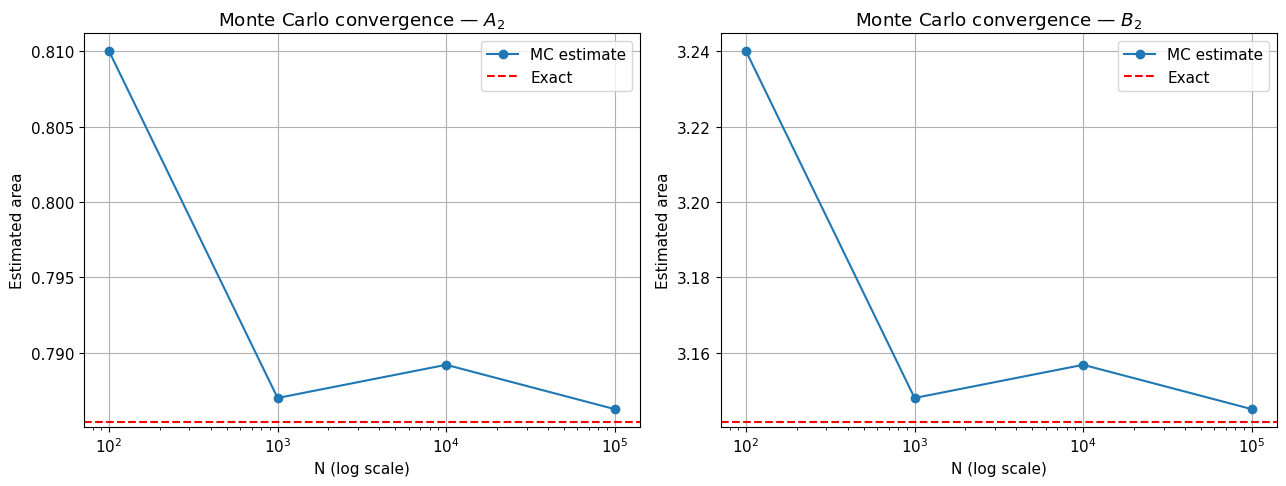

In [ ]:
# ── Convergence plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label in zip(axes, [df_A2, df_B2], ["$A_2$","$B_2$"]):
    ax.plot(df["N"], df["estimate"], "o-", label="MC estimate")
    ax.axhline(df["exact"].iloc[0], ls="--", color="red", label="Exact")
    ax.set(xscale="log", title=f"Monte Carlo convergence — {label}",
           xlabel="N (log scale)", ylabel="Estimated area")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Monte Carlo convergence across N for A3, B3 ─────────────────────────────────
df_A3 = sweep_N("A", n=3)
df_B3 = sweep_N("B", n=3)

cols = ["shape","n","N","exact","estimate","abs_error","rel_error","hit_rate","runtime"]
pd.concat([df_A3, df_B3])[cols].round(6)

---
## Diagnostic — Good versus bad bounding boxes

This test connects to the lecture idea. A larger bounding box wastes samples outside the target region. This helps explain why high-dimensional bounding-box Monte Carlo later fails.


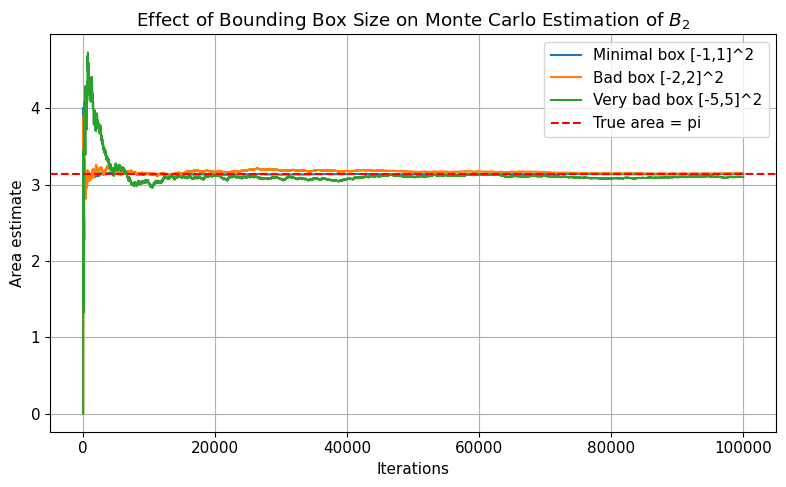

,box,R,box_area,hit_rate,final_estimate,absolute_error,relative_error
0,"Minimal box [-1,1]^2",1.0,4.0,0.78385,3.1354,0.006193,0.001971
1,"Bad box [-2,2]^2",2.0,16.0,0.19700,3.1520,0.010407,0.003313
2,"Very bad box [-5,5]^2",5.0,100.0,0.03097,3.0970,0.044593,0.014194


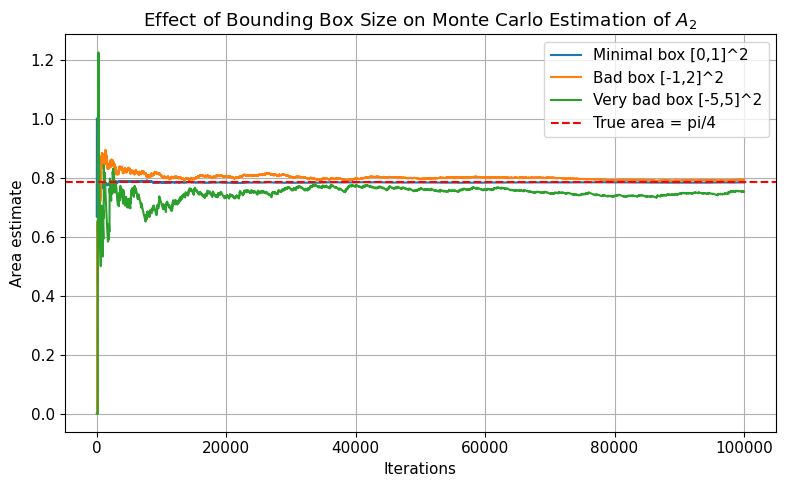

,box,box_area,hit_rate,final_estimate,absolute_error,relative_error
0,"Minimal box [0,1]^2",1.0,0.78385,0.78385,0.001548,0.001971
1,"Bad box [-1,2]^2",9.0,0.08814,0.79326,0.007862,0.010010
2,"Very bad box [-5,5]^2",100.0,0.00753,0.75300,0.032398,0.041251


In [ ]:
# ============================================================
# Effect of bounding box size on Monte Carlo estimation
# Example: estimate area of B_2 using different bounding boxes
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


def mc_running_estimate_B2_box(N=100000, R=1.0, seed=42):
    """
    Estimate area of B_2 using bounding box [-R, R]^2.
    Returns running estimates.
    """
    rng = np.random.default_rng(seed)

    x = rng.uniform(-R, R, size=(N, 2))
    inside = np.sum(x ** 2, axis=1) <= 1.0

    box_area = (2 * R) ** 2

    cumulative_hits = np.cumsum(inside)
    iterations = np.arange(1, N + 1)

    running_estimate = box_area * cumulative_hits / iterations

    return iterations, running_estimate, inside


N = 100000
true_area_B2 = math.pi

box_settings = [
    ("Minimal box [-1,1]^2", 1.0),
    ("Bad box [-2,2]^2", 2.0),
    ("Very bad box [-5,5]^2", 5.0),
]

plt.figure(figsize=(8, 5))

summary_rows = []

for label, R in box_settings:
    iterations, running_estimate, inside = mc_running_estimate_B2_box(
        N=N,
        R=R,
        seed=42
    )

    plt.plot(iterations, running_estimate, label=label)

    final_estimate = running_estimate[-1]
    abs_error = abs(final_estimate - true_area_B2)
    rel_error = abs_error / true_area_B2
    hit_rate = np.mean(inside)

    summary_rows.append({
        "box": label,
        "R": R,
        "box_area": (2 * R) ** 2,
        "hit_rate": hit_rate,
        "final_estimate": final_estimate,
        "absolute_error": abs_error,
        "relative_error": rel_error
    })

Bn = plt.axhline(true_area_B2, linestyle="--", color="red", label="True area = pi")
plt.title("Effect of Bounding Box Size on Monte Carlo Estimation of $B_2$")
plt.xlabel("Iterations")
plt.ylabel("Area estimate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

box_effect_summary = pd.DataFrame(summary_rows)
display(box_effect_summary)

# ============================================================
# Effect of bounding box size on Monte Carlo estimation
# Example: estimate area of A_2 using different bounding boxes
# ============================================================


def mc_running_estimate_A2_box(N=100000, low=0.0, high=1.0, seed=42):
    """
    Estimate area of A_2 using bounding box [low, high]^2.
    A_2 center is (0.5, 0.5), radius 0.5.
    """
    rng = np.random.default_rng(seed)

    x = rng.uniform(low, high, size=(N, 2))
    inside = np.sum((x - 0.5) ** 2, axis=1) <= 0.5 ** 2

    box_area = (high - low) ** 2

    cumulative_hits = np.cumsum(inside)
    iterations = np.arange(1, N + 1)

    running_estimate = box_area * cumulative_hits / iterations

    return iterations, running_estimate, inside


N = 100000
true_area_A2 = math.pi / 4

box_settings_A = [
    ("Minimal box [0,1]^2", 0.0, 1.0),
    ("Bad box [-1,2]^2", -1.0, 2.0),
    ("Very bad box [-5,5]^2", -5.0, 5.0),
]

plt.figure(figsize=(8, 5))

summary_rows_A = []

for label, low, high in box_settings_A:
    iterations, running_estimate, inside = mc_running_estimate_A2_box(
        N=N,
        low=low,
        high=high,
        seed=42
    )

    plt.plot(iterations, running_estimate, label=label)

    final_estimate = running_estimate[-1]
    abs_error = abs(final_estimate - true_area_A2)
    rel_error = abs_error / true_area_A2
    hit_rate = np.mean(inside)

    summary_rows_A.append({
        "box": label,
        "box_area": (high - low) ** 2,
        "hit_rate": hit_rate,
        "final_estimate": final_estimate,
        "absolute_error": abs_error,
        "relative_error": rel_error
    })

An = plt.axhline(true_area_A2, linestyle="--", color="red", label="True area = pi/4")
plt.title("Effect of Bounding Box Size on Monte Carlo Estimation of $A_2$")
plt.xlabel("Iterations")
plt.ylabel("Area estimate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

box_effect_summary_A = pd.DataFrame(summary_rows_A)
display(box_effect_summary_A)

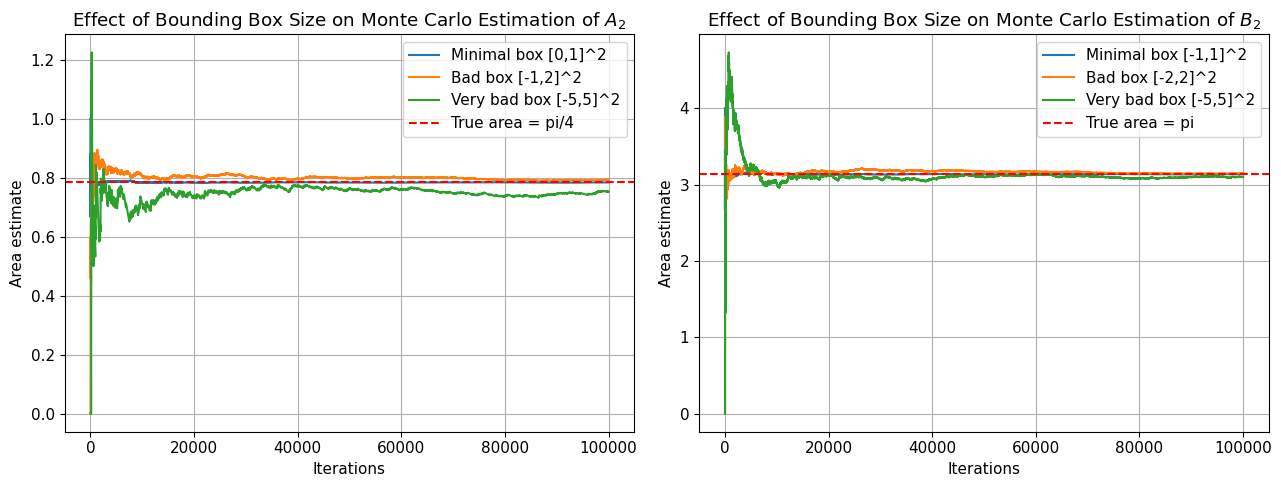

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left subplot: A2
for label, low, high in box_settings_A:
    iterations, running_estimate, inside = mc_running_estimate_A2_box(
        N=N,
        low=low,
        high=high,
        seed=42
    )
    axes[0].plot(iterations, running_estimate, label=label)

axes[0].axhline(true_area_A2, linestyle="--", color="red", label="True area = pi/4")
axes[0].set_title("Effect of Bounding Box Size on Monte Carlo Estimation of $A_2$")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Area estimate")
axes[0].legend()
axes[0].grid(True)

# Right subplot: B2
for label, R in box_settings:
    iterations, running_estimate, inside = mc_running_estimate_B2_box(
        N=N,
        R=R,
        seed=42
    )
    axes[1].plot(iterations, running_estimate, label=label)

axes[1].axhline(true_area_B2, linestyle="--", color="red", label="True area = pi")
axes[1].set_title("Effect of Bounding Box Size on Monte Carlo Estimation of $B_2$")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Area estimate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Optional check: Sobol Quasi-Monte Carlo

We also tested Sobol quasi-Monte Carlo because it spreads points more evenly than ordinary random Monte Carlo. This can reduce random clustering in low dimensions. However, it still samples from the bounding box, so it cannot solve the high-dimensional zero-hit problem when the ball occupies an extremely small fraction of the box.


In [ ]:
# ============================================================
# Optional: Crude Monte Carlo vs Sobol Quasi-Monte Carlo
# ============================================================

qmc_dims = [2, 3, 5, 10, 20]
qmc_N = 4096
qmc_m = int(np.log2(qmc_N))

qmc_rows = []

for shape in ["A", "B"]:
    for n in qmc_dims:
        exact = exact_vol(shape, n)

        crude = monte_carlo(
            shape=shape,
            n=n,
            N=qmc_N,
            seed=SEED + 100 + n
        )

        qmc_result = quasi_mc(
            shape=shape,
            n=n,
            m=qmc_m,
            seed=SEED + 200 + n
        )

        if isinstance(qmc_result, dict):
            qmc_estimate = qmc_result["estimate"]
            qmc_hits = qmc_result["hits"]
        else:
            qmc_estimate, qmc_hits = qmc_result

        qmc_rows.append({
            "shape": shape,
            "n": n,
            "exact": exact,
            "crude_mc_estimate": crude["estimate"],
            "crude_mc_hits": crude["hits"],
            "crude_mc_abs_error": abs(crude["estimate"] - exact),
            "qmc_estimate": qmc_estimate,
            "qmc_hits": qmc_hits,
            "qmc_abs_error": abs(qmc_estimate - exact)
        })

qmc_summary = pd.DataFrame(qmc_rows)
display(qmc_summary)


,shape,n,exact,crude_mc_estimate,crude_mc_hits,crude_mc_abs_error,qmc_estimate,qmc_hits,qmc_abs_error
0,A,2,7.853982e-01,0.780762,3198,4.636445e-03,0.785156,3216,2.419134e-04
1,A,3,5.235988e-01,0.520020,2130,3.579244e-03,0.523926,2146,3.270057e-04
2,A,5,1.644934e-01,0.164795,675,3.015152e-04,0.164795,675,3.015152e-04
3,A,10,2.490395e-03,0.002441,10,4.898832e-05,0.002686,11,1.951523e-04
4,A,20,2.461137e-08,0.000000,0,2.461137e-08,0.000000,0,2.461137e-08
5,B,2,3.141593e+00,3.123047,3198,1.854578e-02,3.140625,3216,9.676536e-04
6,B,3,4.188790e+00,4.160156,2130,2.863395e-02,4.191406,2146,2.616045e-03
7,B,5,5.263789e+00,5.273438,675,9.648486e-03,5.273438,675,9.648486e-03
8,B,10,2.550164e+00,2.500000,10,5.016404e-02,2.750000,11,1.998360e-01
9,B,20,2.580689e-02,0.000000,0,2.580689e-02,0.000000,0,2.580689e-02


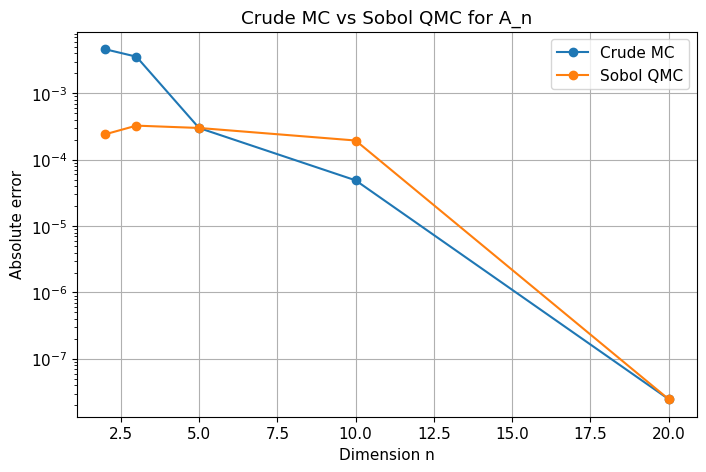

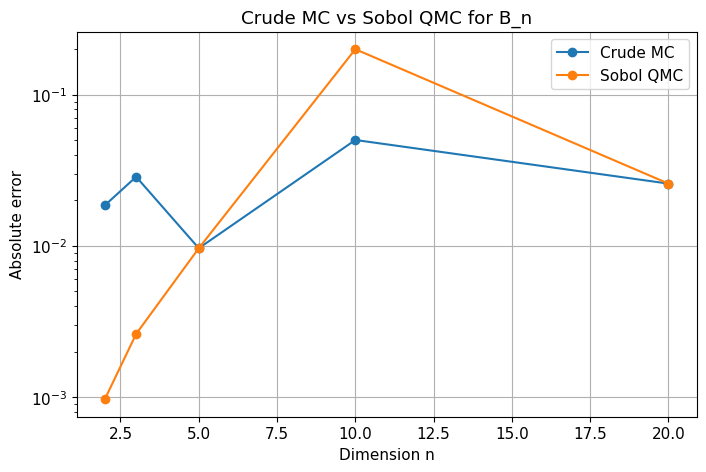

In [ ]:
# ============================================================
# Plot crude MC vs Sobol QMC absolute error
# ============================================================

for shape in ["A", "B"]:
    sub = qmc_summary[qmc_summary["shape"] == shape]

    plt.figure(figsize=(8, 5))

    plt.plot(
        sub["n"],
        sub["crude_mc_abs_error"],
        marker="o",
        label="Crude MC"
    )

    plt.plot(
        sub["n"],
        sub["qmc_abs_error"],
        marker="o",
        label="Sobol QMC"
    )

    plt.yscale("log")
    plt.title(f"Crude MC vs Sobol QMC for {shape}_n")
    plt.xlabel("Dimension n")
    plt.ylabel("Absolute error")
    plt.legend()
    plt.grid(True)
    plt.show()


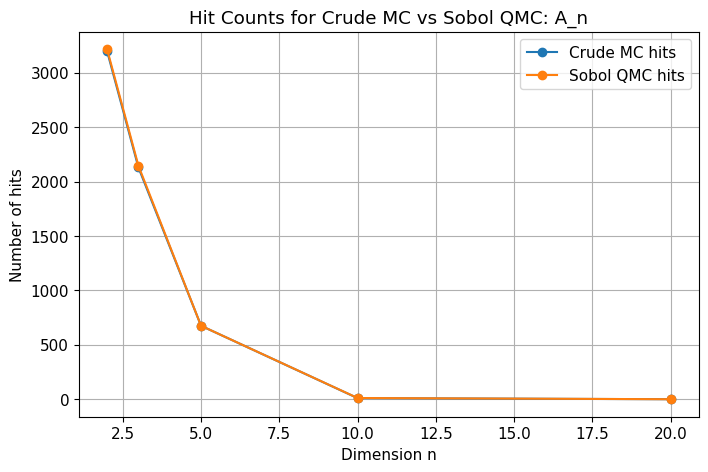

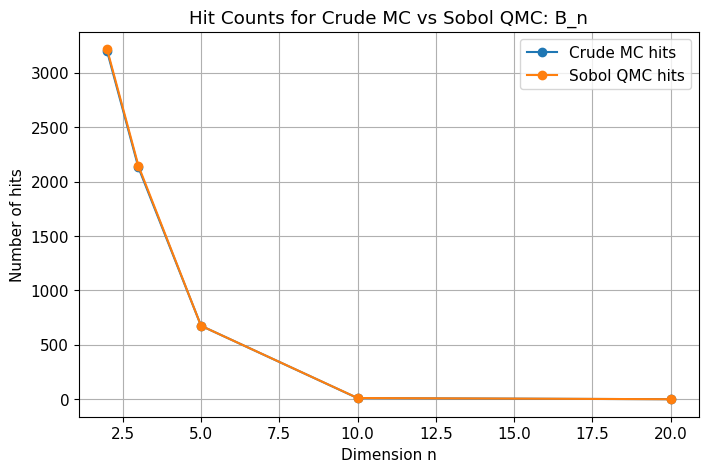

In [ ]:
# ============================================================
# Hit counts: crude MC vs Sobol QMC
# ============================================================

for shape in ["A", "B"]:
    sub = qmc_summary[qmc_summary["shape"] == shape]

    plt.figure(figsize=(8, 5))

    plt.plot(
        sub["n"],
        sub["crude_mc_hits"],
        marker="o",
        label="Crude MC hits"
    )

    plt.plot(
        sub["n"],
        sub["qmc_hits"],
        marker="o",
        label="Sobol QMC hits"
    )

    plt.title(f"Hit Counts for Crude MC vs Sobol QMC: {shape}_n")
    plt.xlabel("Dimension n")
    plt.ylabel("Number of hits")
    plt.legend()
    plt.grid(True)
    plt.show()


---
## Part 1.b — $A_3$ and $B_3$ (3-D)

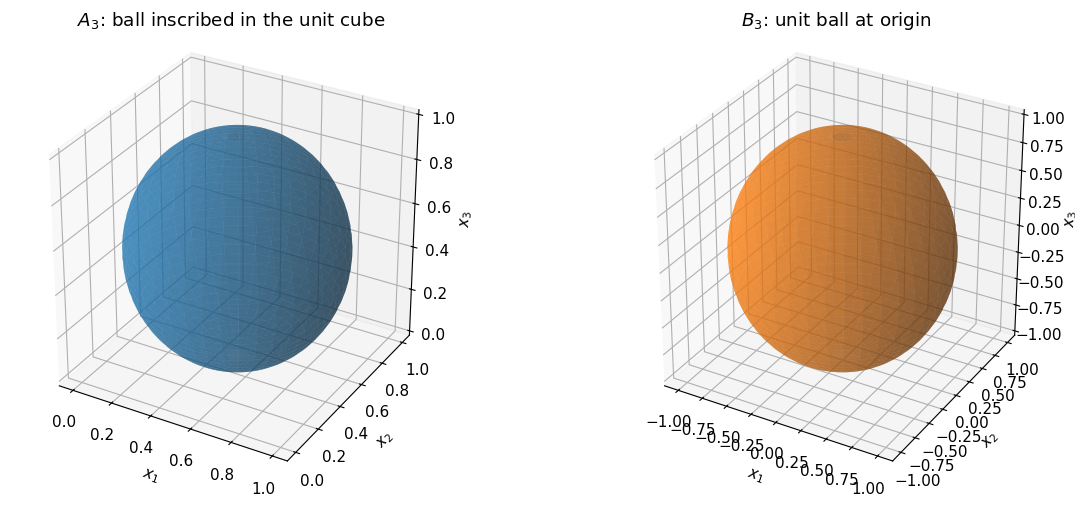

Exact volume A3 = π/6   = 0.523599
Exact volume B3 = 4π/3  = 4.188790


In [ ]:
# ── Visualise ──────────────────────────────────────────────────────────────────
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0,   np.pi, 40)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(0.5+0.5*xs, 0.5+0.5*ys, 0.5+0.5*zs, alpha=0.55, color="C0")
ax.set(title="$A_3$: ball inscribed in the unit cube",
       xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect([1,1,1])

ax = fig.add_subplot(122, projection="3d")
ax.plot_surface(xs, ys, zs, alpha=0.55, color="C1")
ax.set(title="$B_3$: unit ball at origin",
       xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print(f"Exact volume A3 = π/6   = {exact_vol('A',3):.6f}")
print(f"Exact volume B3 = 4π/3  = {exact_vol('B',3):.6f}")

In [ ]:
# ── Monte Carlo — same sweep_N call, just change n ───────────────────────────
df_A3 = sweep_N("A", n=3)
df_B3 = sweep_N("B", n=3)

pd.concat([df_A3, df_B3])[cols].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error,hit_rate,runtime
0,A,3,100,0.523599,0.51000,0.013599,0.025972,0.51000,0.000107
1,A,3,1000,0.523599,0.52600,0.002401,0.004586,0.52600,0.000110
2,A,3,10000,0.523599,0.52620,0.002601,0.004968,0.52620,0.000670
3,A,3,100000,0.523599,0.52539,0.001791,0.003421,0.52539,0.009431
0,B,3,100,4.188790,4.08000,0.108790,0.025972,0.51000,0.000053
1,B,3,1000,4.188790,4.20800,0.019210,0.004586,0.52600,0.000051
2,B,3,10000,4.188790,4.20960,0.020810,0.004968,0.52620,0.000334
3,B,3,100000,4.188790,4.20312,0.014330,0.003421,0.52539,0.003784


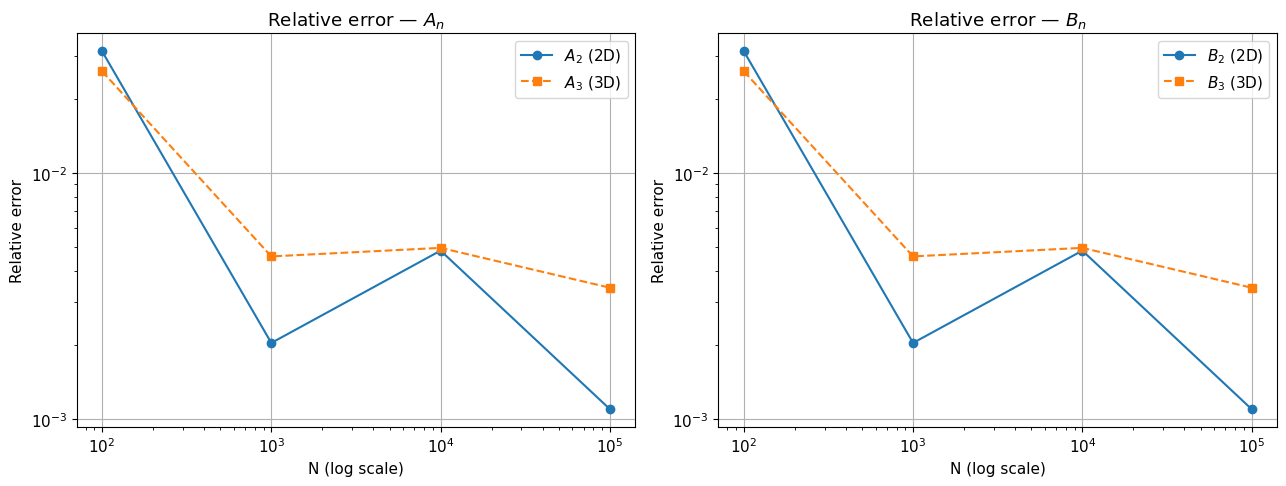

In [ ]:
# ── Side-by-side comparison 2D vs 3D ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df2, df3, label in zip(axes, [df_A2, df_B2], [df_A3, df_B3], ["A","B"]):
    ax.plot(df2["N"], df2["rel_error"], "o-", label=f"${label}_2$ (2D)")
    ax.plot(df3["N"], df3["rel_error"], "s--", label=f"${label}_3$ (3D)")
    ax.set(xscale="log", yscale="log",
           title=f"Relative error — ${label}_n$",
           xlabel="N (log scale)", ylabel="Relative error")
    ax.legend()

plt.tight_layout()
plt.show()

---
## Part 1.c — General $n$, high-dimensional failure, and the curse of dimensionality

In [ ]:
# ── Exact volume table (all computed from one function call) ──────────────────
et = exact_table()
et.round(8)

,n,log_vol_A,log_vol_B,vol_A,vol_B,log_hit_rate_A,log_hit_rate_B
0,1,0.000000,0.693147,1.000000e+00,2.000000,0.000000,0.000000
1,2,-0.241564,1.144730,7.853982e-01,3.141593,-0.241564,-0.241564
2,3,-0.647030,1.432412,5.235988e-01,4.188790,-0.647030,-0.647030
3,5,-1.804885,1.660851,1.644934e-01,5.263789,-1.804885,-1.804885
4,10,-5.995314,0.936158,2.490390e-03,2.550164,-5.995314,-5.995314
5,20,-17.520057,-3.657114,2.000000e-08,0.025807,-17.520057,-17.520057
6,50,-64.042717,-29.385358,0.000000e+00,0.000000,-64.042717,-64.042717
7,100,-160.555991,-91.241273,0.000000e+00,0.000000,-160.555991,-160.555991


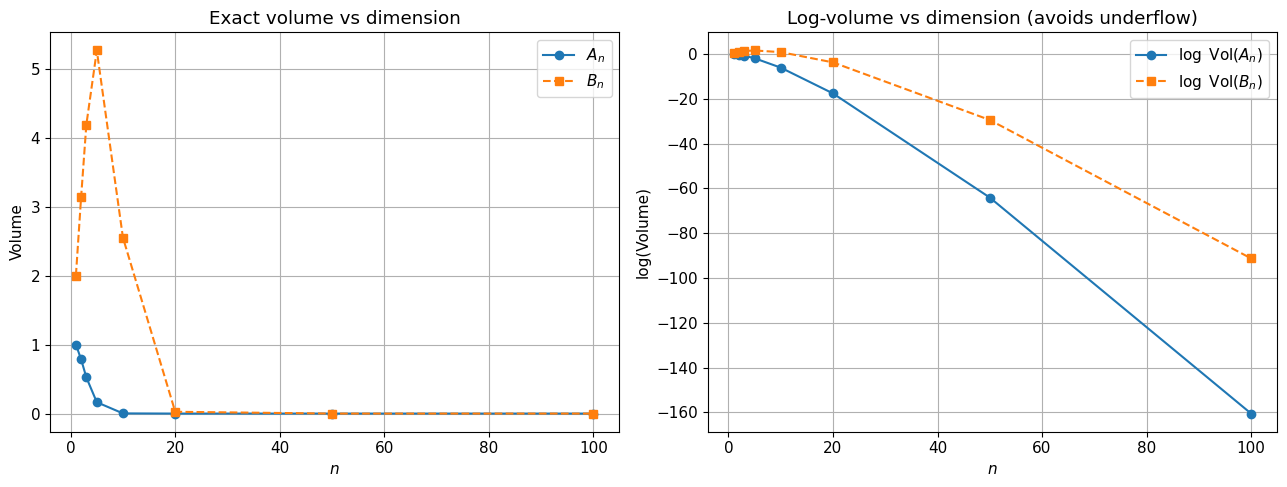

In [ ]:
# ── Volume and log-volume plots across dimensions ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(et["n"], et["vol_A"],   "o-", label="$A_n$")
axes[0].plot(et["n"], et["vol_B"],   "s--", label="$B_n$")
axes[0].set(title="Exact volume vs dimension", xlabel="$n$", ylabel="Volume")
axes[0].legend()

axes[1].plot(et["n"], et["log_vol_A"], "o-", label="$\\log$ Vol$(A_n)$")
axes[1].plot(et["n"], et["log_vol_B"], "s--", label="$\\log$ Vol$(B_n)$")
axes[1].set(title="Log-volume vs dimension (avoids underflow)",
            xlabel="$n$", ylabel="log(Volume)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Monte Carlo at n=100 (expect 0 hits) ──────────────────────────────────────
rows_100 = []
for shape in ["A", "B"]:
    for N in [1_000, 10_000, 100_000]:
        rows_100.append(monte_carlo(shape, n=100, N=N, chunk=10_000))

df_100 = pd.DataFrame(rows_100)

# Log-exact from formula:
df_100["log_exact"] = df_100.apply(
    lambda r: log_vol_A(100) if r["shape"]=="A" else log_vol_B(100), axis=1)

df_100[["shape","n","N","hits","hit_rate","estimate","log_exact"]].to_string(index=False)
df_100[["shape","n","N","hits","hit_rate","estimate","log_exact"]]

,shape,n,N,hits,hit_rate,estimate,log_exact
0,A,100,1000,0,0.0,0.0,-160.555991
1,A,100,10000,0,0.0,0.0,-160.555991
2,A,100,100000,0,0.0,0.0,-160.555991
3,B,100,1000,0,0.0,0.0,-91.241273
4,B,100,10000,0,0.0,0.0,-91.241273
5,B,100,100000,0,0.0,0.0,-91.241273


---
## Part 1.c diagnostic — Curse of dimensionality

The n=100 failure is explained by the collapse of hit probability. The key metric is not ACF. The key metric is the probability that a uniformly sampled box point lands inside the ball.


In [ ]:
# ============================================================
# Curse of dimensionality: theoretical hit probability
# ============================================================

curse_dims = (2, 3, 5, 10, 20, 50, 100)

curse_rows = []

for n in curse_dims:
    lA, lB = log_vol_A(n), log_vol_B(n)

    # For A_n, bounding box volume is 1.
    log_hit_A = lA

    # For B_n, bounding box volume is 2^n.
    log_hit_B = lB - n * np.log(2)

    curse_rows.append({
        "n": n,
        "log_volume_A": lA,
        "log_volume_B": lB,
        "log_hit_rate_A": log_hit_A,
        "log_hit_rate_B": log_hit_B,
        "hit_rate_A": np.exp(log_hit_A) if log_hit_A > -745 else 0.0,
        "hit_rate_B": np.exp(log_hit_B) if log_hit_B > -745 else 0.0,
        "log10_hit_rate_A": log_hit_A / np.log(10),
        "log10_hit_rate_B": log_hit_B / np.log(10),
    })

hit_rate_df = pd.DataFrame(curse_rows)

display(hit_rate_df)

,n,log_volume_A,log_volume_B,log_hit_rate_A,log_hit_rate_B,hit_rate_A,hit_rate_B,log10_hit_rate_A,log10_hit_rate_B
0,2,-0.241564,1.144730,-0.241564,-0.241564,7.853982e-01,7.853982e-01,-0.104910,-0.104910
1,3,-0.647030,1.432412,-0.647030,-0.647030,5.235988e-01,5.235988e-01,-0.281001,-0.281001
2,5,-1.804885,1.660851,-1.804885,-1.804885,1.644934e-01,1.644934e-01,-0.783852,-0.783852
3,10,-5.995314,0.936158,-5.995314,-5.995314,2.490395e-03,2.490395e-03,-2.603732,-2.603732
4,20,-17.520057,-3.657114,-17.520057,-17.520057,2.461137e-08,2.461137e-08,-7.608864,-7.608864
5,50,-64.042717,-29.385358,-64.042717,-64.042717,1.536743e-28,1.536743e-28,-27.813399,-27.813399
6,100,-160.555991,-91.241273,-160.555991,-160.555991,1.868182e-70,1.868182e-70,-69.728581,-69.728581


In [ ]:
# ============================================================
# Samples needed for at least one hit with 95% probability
# ============================================================

required_rows = []

for _, row in hit_rate_df.iterrows():
    n = int(row["n"])

    for shape_name in ["A", "B"]:
        log_hit = row[f"log_hit_rate_{shape_name}"]

        # For small p, log_N_95 ≈ log(-log(0.05)) - log(p)
        # This is more stable than computing p directly.
        log_N_95 = np.log(-np.log(0.05)) - log_hit

        required_rows.append({
            "shape": shape_name,
            "n": n,
            "log_N_95_one_hit": log_N_95,
            "log10_N_95_one_hit": log_N_95 / np.log(10)
        })

required_N_table = pd.DataFrame(required_rows)

display(required_N_table)

,shape,n,log_N_95_one_hit,log10_N_95_one_hit
0,A,2,1.338753,0.581413
1,B,2,1.338753,0.581413
2,A,3,1.744218,0.757504
3,B,3,1.744218,0.757504
4,A,5,2.902073,1.260355
5,B,5,2.902073,1.260355
6,A,10,7.092503,3.080235
7,B,10,7.092503,3.080235
8,A,20,18.617246,8.085367
9,B,20,18.617246,8.085367


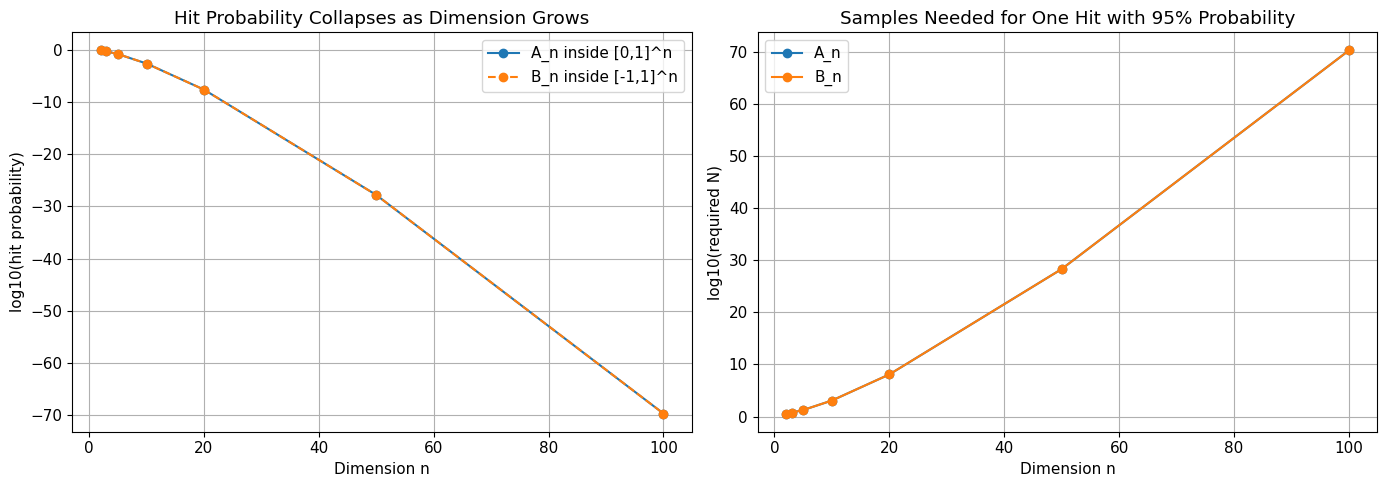

In [ ]:
# ============================================================
# Plot curse of dimensionality
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot hit probability collapse
ax[0].plot(
    hit_rate_df["n"],
    hit_rate_df["log10_hit_rate_A"],
    marker="o",
    label="A_n inside [0,1]^n"
)

ax[0].plot(
    hit_rate_df["n"],
    hit_rate_df["log10_hit_rate_B"],
    marker="o",
    linestyle="--",
    label="B_n inside [-1,1]^n"
)

ax[0].set_title("Hit Probability Collapses as Dimension Grows")
ax[0].set_xlabel("Dimension n")
ax[0].set_ylabel("log10(hit probability)")
ax[0].legend()
ax[0].grid(True)

# Plot required sample size
for shape_name in ["A", "B"]:
    sub = required_N_table[required_N_table["shape"] == shape_name]

    ax[1].plot(
        sub["n"],
        sub["log10_N_95_one_hit"],
        marker="o",
        label=f"{shape_name}_n"
    )

ax[1].set_title("Samples Needed for One Hit with 95% Probability")
ax[1].set_xlabel("Dimension n")
ax[1].set_ylabel("log10(required N)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

---
## Part 1.d — Selected improvement: recursive slicing and log-volume

After the curse-of-dimensionality diagnosis, we need a method that does not depend on rare random hits. Recursive slicing computes the ball volume through one-dimensional cross-sectional integrals. Log-volume keeps the calculation stable for high dimensions.


In [ ]:
# ============================================================
# Recursive slicing / cross-sectional integration
# Problem 1 improvement method
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from scipy.integrate import quad
from scipy.special import gammaln


# ------------------------------------------------------------
# Exact log-volume by Gamma formula
# Used as benchmark
# ------------------------------------------------------------

def exact_log_volume_B(n):
    """
    Exact log-volume of the n-dimensional unit ball B_n.

    Vol(B_n) = pi^(n/2) / Gamma(n/2 + 1)
    """
    return (n / 2) * math.log(math.pi) - gammaln(n / 2 + 1)


def exact_log_volume_A(n):
    """
    Exact log-volume of A_n.

    A_n has radius 1/2, so:
    Vol(A_n) = 2^(-n) Vol(B_n)
    """
    return exact_log_volume_B(n) - n * math.log(2)


def safe_exp(log_value):
    """
    Convert log-value to normal scale safely.
    Returns 0 if the value underflows in floating point.
    """
    if log_value < -745:
        return 0.0
    return math.exp(log_value)


# ------------------------------------------------------------
# Cross-sectional integral
# ------------------------------------------------------------

def cross_section_integral(n, epsabs=1e-12, epsrel=1e-12):
    """
    Compute the 1D integral:

        I_n = integral from -1 to 1 of (1 - t^2)^((n-1)/2) dt

    Then:
        Vol(B_n) = Vol(B_{n-1}) * I_n
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    exponent = (n - 1) / 2

    def integrand(t):
        return (1 - t * t) ** exponent

    value, error = quad(
        integrand,
        -1.0,
        1.0,
        epsabs=epsabs,
        epsrel=epsrel,
        limit=200
    )

    return value, error


def recursive_slicing_log_volume_B(n, epsabs=1e-12, epsrel=1e-12):
    """
    Compute log Vol(B_n) using recursive cross-sectional integration.

    Base case:
        Vol(B_0) = 1

    Recursive formula:
        Vol(B_k) = Vol(B_{k-1}) * I_k

    where:
        I_k = integral from -1 to 1 of (1 - t^2)^((k-1)/2) dt
    """
    if n < 0:
        raise ValueError("n must be >= 0")

    log_volume = 0.0  # log Vol(B_0) = log(1) = 0

    integral_errors = []

    for k in range(1, n + 1):
        integral_value, integral_error = cross_section_integral(
            k,
            epsabs=epsabs,
            epsrel=epsrel
        )

        log_volume += math.log(integral_value)

        integral_errors.append({
            "k": k,
            "integral_value": integral_value,
            "integral_error": integral_error
        })

    return log_volume, pd.DataFrame(integral_errors)


def recursive_slicing_log_volume_A(n, epsabs=1e-12, epsrel=1e-12):
    """
    Compute log Vol(A_n) from recursive slicing result for B_n.
    """
    log_B, error_df = recursive_slicing_log_volume_B(
        n,
        epsabs=epsabs,
        epsrel=epsrel
    )

    log_A = log_B - n * math.log(2)

    return log_A, error_df


In [ ]:
# ============================================================
# Compare Gamma formula and recursive slicing
# ============================================================

slicing_dims = [1, 2, 3, 5, 10, 20, 50, 100]

slicing_rows = []

for n in slicing_dims:
    gamma_log_B = exact_log_volume_B(n)
    gamma_log_A = exact_log_volume_A(n)

    slicing_log_B, slicing_error_df = recursive_slicing_log_volume_B(n)
    slicing_log_A = slicing_log_B - n * math.log(2)

    slicing_rows.append({
        "n": n,

        "gamma_log_volume_B": gamma_log_B,
        "slicing_log_volume_B": slicing_log_B,
        "abs_log_error_B": abs(slicing_log_B - gamma_log_B),

        "gamma_log_volume_A": gamma_log_A,
        "slicing_log_volume_A": slicing_log_A,
        "abs_log_error_A": abs(slicing_log_A - gamma_log_A),

        "gamma_volume_B": safe_exp(gamma_log_B),
        "slicing_volume_B": safe_exp(slicing_log_B),

        "gamma_volume_A": safe_exp(gamma_log_A),
        "slicing_volume_A": safe_exp(slicing_log_A),

        "max_integral_error": slicing_error_df["integral_error"].max()
    })

slicing_summary = pd.DataFrame(slicing_rows)

display(slicing_summary)


,n,gamma_log_volume_B,slicing_log_volume_B,abs_log_error_B,gamma_log_volume_A,slicing_log_volume_A,abs_log_error_A,gamma_volume_B,slicing_volume_B,gamma_volume_A,slicing_volume_A,max_integral_error
0,1,0.693147,0.693147,1.110223e-16,1.110223e-16,0.000000,1.110223e-16,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,2.220446e-14
1,2,1.144730,1.144730,6.661338e-16,-2.415645e-01,-0.241564,6.661338e-16,3.141593e+00,3.141593e+00,7.853982e-01,7.853982e-01,2.575717e-14
2,3,1.432412,1.432412,6.661338e-16,-6.470296e-01,-0.647030,6.661338e-16,4.188790e+00,4.188790e+00,5.235988e-01,5.235988e-01,2.575717e-14
3,5,1.660851,1.660851,6.661338e-16,-1.804885e+00,-1.804885,6.661338e-16,5.263789e+00,5.263789e+00,1.644934e-01,1.644934e-01,5.646594e-13
4,10,0.936158,0.936158,3.552714e-15,-5.995314e+00,-5.995314,3.552714e-15,2.550164e+00,2.550164e+00,2.490395e-03,2.490395e-03,7.098862e-13
5,20,-3.657114,-3.657114,1.776357e-15,-1.752006e+01,-17.520057,0.000000e+00,2.580689e-02,2.580689e-02,2.461137e-08,2.461137e-08,7.098862e-13
6,50,-29.385358,-29.385358,7.105427e-15,-6.404272e+01,-64.042717,0.000000e+00,1.730219e-13,1.730219e-13,1.536743e-28,1.536743e-28,8.908054e-13
7,100,-91.241273,-91.241273,1.421085e-14,-1.605560e+02,-160.555991,2.842171e-14,2.368202e-40,2.368202e-40,1.868182e-70,1.868182e-70,8.908054e-13


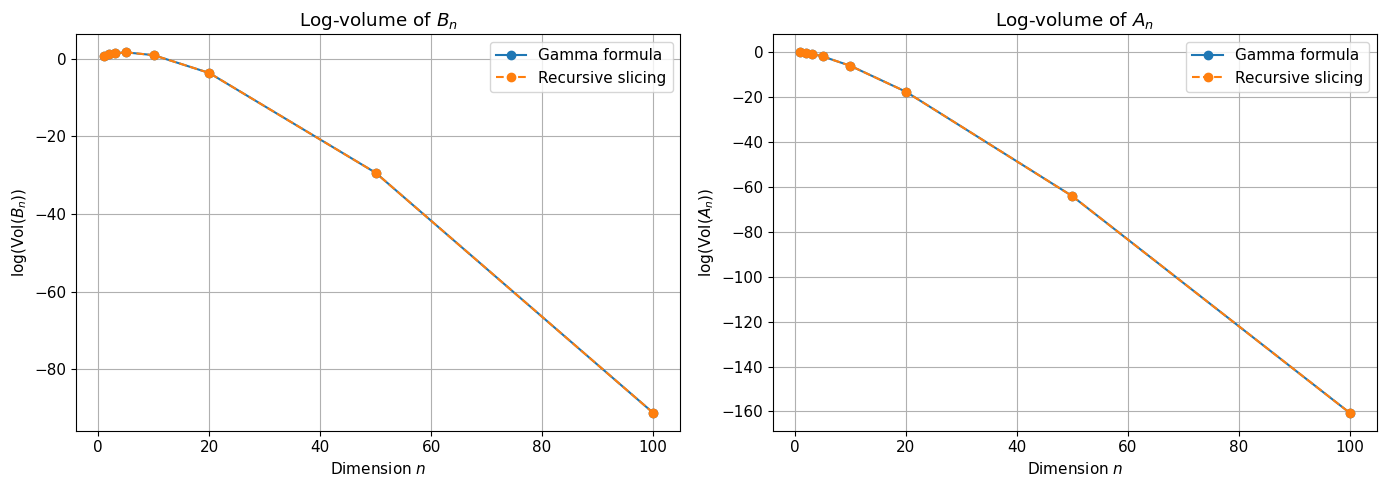

In [ ]:
# ============================================================
# Plot log-volume comparison
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(
    slicing_summary["n"],
    slicing_summary["gamma_log_volume_B"],
    marker="o",
    label="Gamma formula"
)

ax[0].plot(
    slicing_summary["n"],
    slicing_summary["slicing_log_volume_B"],
    marker="o",
    linestyle="--",
    label="Recursive slicing"
)

ax[0].set_title("Log-volume of $B_n$")
ax[0].set_xlabel("Dimension $n$")
ax[0].set_ylabel("$\log(\mathrm{Vol}(B_n))$")
ax[0].legend()
ax[0].grid(True)


ax[1].plot(
    slicing_summary["n"],
    slicing_summary["gamma_log_volume_A"],
    marker="o",
    label="Gamma formula"
)

ax[1].plot(
    slicing_summary["n"],
    slicing_summary["slicing_log_volume_A"],
    marker="o",
    linestyle="--",
    label="Recursive slicing"
)

ax[1].set_title("Log-volume of $A_n$")
ax[1].set_xlabel("Dimension $n$")
ax[1].set_ylabel("$\log(\mathrm{Vol}(A_n))$")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# High-dimensional improvement table
# ============================================================

n = 100

log_B_gamma = exact_log_volume_B(n)
log_A_gamma = exact_log_volume_A(n)

log_B_slicing, _ = recursive_slicing_log_volume_B(n)
log_A_slicing = log_B_slicing - n * math.log(2)

high_dim_improvement = pd.DataFrame([
    {
        "shape": "A_100",
        "method": "Bounding-box MC",
        "estimate": 0.0,
        "log_estimate": -np.inf,
        "comment": "Zero hits with practical N"
    },
    {
        "shape": "A_100",
        "method": "Recursive slicing",
        "estimate": safe_exp(log_A_slicing),
        "log_estimate": log_A_slicing,
        "comment": "Stable high-dimensional computation"
    },
    {
        "shape": "A_100",
        "method": "Gamma formula",
        "estimate": safe_exp(log_A_gamma),
        "log_estimate": log_A_gamma,
        "comment": "Exact benchmark"
    },
    {
        "shape": "B_100",
        "method": "Bounding-box MC",
        "estimate": 0.0,
        "log_estimate": -np.inf,
        "comment": "Zero hits with practical N"
    },
    {
        "shape": "B_100",
        "method": "Recursive slicing",
        "estimate": safe_exp(log_B_slicing),
        "log_estimate": log_B_slicing,
        "comment": "Stable high-dimensional computation"
    },
    {
        "shape": "B_100",
        "method": "Gamma formula",
        "estimate": safe_exp(log_B_gamma),
        "log_estimate": log_B_gamma,
        "comment": "Exact benchmark"
    }
])

display(high_dim_improvement)


,shape,method,estimate,log_estimate,comment
0,A_100,Bounding-box MC,0.000000e+00,-inf,Zero hits with practical N
1,A_100,Recursive slicing,1.868182e-70,-160.555991,Stable high-dimensional computation
2,A_100,Gamma formula,1.868182e-70,-160.555991,Exact benchmark
3,B_100,Bounding-box MC,0.000000e+00,-inf,Zero hits with practical N
4,B_100,Recursive slicing,2.368202e-40,-91.241273,Stable high-dimensional computation
5,B_100,Gamma formula,2.368202e-40,-91.241273,Exact benchmark


In [ ]:
# ── Repeated MC: shows variance and zero-hit fraction ─────────────────────────
rep_dims  = [2, 3, 5, 10, 20]
rep_rows  = [repeated_mc(s, n) for s in ["A","B"] for n in rep_dims]
rep_df    = pd.DataFrame(rep_rows)

rep_df[["shape","n","mean","std","ci95","zero_hit_frac"]].round(6)

,shape,n,mean,std,ci95,zero_hit_frac
0,A,2,0.785673,0.004013,0.001436,0.0
1,A,3,0.523067,0.004217,0.001509,0.0
2,A,5,0.164917,0.004263,0.001526,0.0
3,A,10,0.002540,0.000512,0.000183,0.0
4,A,20,0.000000,0.000000,0.000000,1.0
5,B,2,3.142693,0.016051,0.005744,0.0
6,B,3,4.184533,0.033738,0.012073,0.0
7,B,5,5.277333,0.136424,0.048819,0.0
8,B,10,2.600960,0.523937,0.187488,0.0
9,B,20,0.000000,0.000000,0.000000,1.0


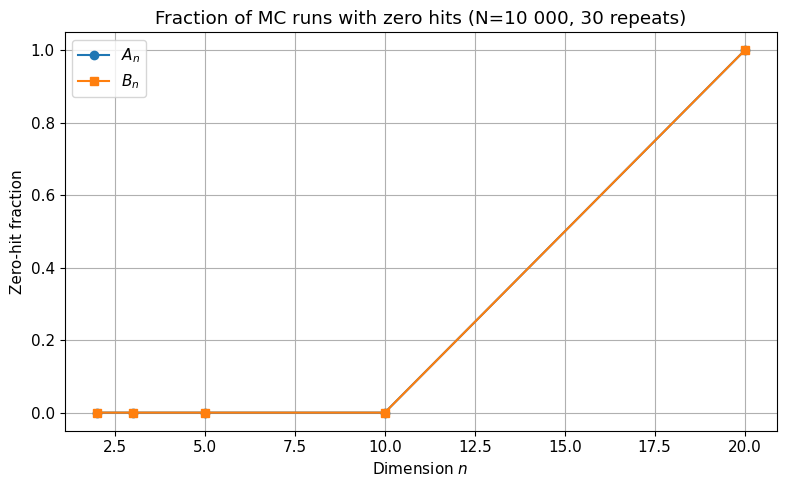

In [ ]:
# ── Zero-hit fraction plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for s, marker in [("A","o"), ("B","s")]:
    sub = rep_df[rep_df["shape"]==s]
    ax.plot(sub["n"], sub["zero_hit_frac"], marker+"-", label=f"${s}_n$")

ax.set(title="Fraction of MC runs with zero hits (N=10 000, 30 repeats)",
       xlabel="Dimension $n$", ylabel="Zero-hit fraction", ylim=(-0.05, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

---
## Supporting method — Direct radial sampling

Direct radial sampling generates valid points inside the ball, so it is useful for geometry and visualization. It is not used as the main volume estimator because every point is already inside the ball by construction.


In [ ]:
def radial_samples(shape: str, n: int, N: int = 4096, seed: int = SEED) -> np.ndarray:
    """
    Generate N points uniformly inside A_n (radius 0.5) or B_n (radius 1)
    using the Muller–Marsaglia direct method. Returns an (N, n) array.
    """
    rng = np.random.default_rng(seed)
    radius = 0.5 if shape == "A" else 1.0
    center = np.full(n, 0.5) if shape == "A" else np.zeros(n)

    Z = rng.standard_normal((N, n))               # random directions
    U = Z / np.linalg.norm(Z, axis=1, keepdims=True)  # normalise to sphere
    R = radius * rng.uniform(size=N) ** (1 / n)   # correct radial density
    return center + R[:, None] * U                # shift for A_n


print("radial_samples() defined.")
print("Sanity check — all generated points should be inside the ball:")
for shape, checker in [("A", in_A), ("B", in_B)]:
    pts = radial_samples(shape, n=3, N=5000)
    frac = checker(pts).mean()
    print(f"  {shape}_3 : {frac*100:.1f}% inside  (expected 100%)")

radial_samples() defined.
Sanity check — all generated points should be inside the ball:
  A_3 : 100.0% inside  (expected 100%)
  B_3 : 100.0% inside  (expected 100%)


### 5.2 Concentration of measure — radial distribution across dimensions

In high dimensions the sampled radii concentrate near the boundary of the ball
(a consequence of the radial density $f(r) \propto r^{n-1}$).
This is the geometric face of the curse of dimensionality.

In [ ]:
dims = [2, 3, 5, 10, 20, 50, 100]
N_radial = 5000

rows_radial = []
for shape in ["A", "B"]:
    radius = 0.5 if shape == "A" else 1.0
    for n in dims:
        pts  = radial_samples(shape, n=n, N=N_radial)
        center = np.full(n, 0.5) if shape == "A" else np.zeros(n)
        R    = np.linalg.norm(pts - center, axis=1)
        rows_radial.append(dict(
            shape=shape, n=n,
            mean_R=R.mean(), std_R=R.std(),
            median_R=np.median(R),
            frac_near_boundary=(R >= 0.9*radius).mean(),  # within 10% of edge
        ))

df_radial = pd.DataFrame(rows_radial)
df_radial.round(4)

,shape,n,mean_R,std_R,median_R,frac_near_boundary
0,A,2,0.3313,0.1186,0.3494,0.1908
1,A,3,0.3748,0.0975,0.3976,0.2708
2,A,5,0.4163,0.0706,0.4355,0.3996
3,A,10,0.4553,0.0408,0.4668,0.6556
4,A,20,0.4763,0.0225,0.4832,0.8812
5,A,50,0.4903,0.0094,0.4931,0.9966
6,A,100,0.4951,0.0047,0.4966,1.0000
7,B,2,0.6625,0.2372,0.6988,0.1908
8,B,3,0.7496,0.1950,0.7952,0.2708
9,B,5,0.8327,0.1412,0.8710,0.3996


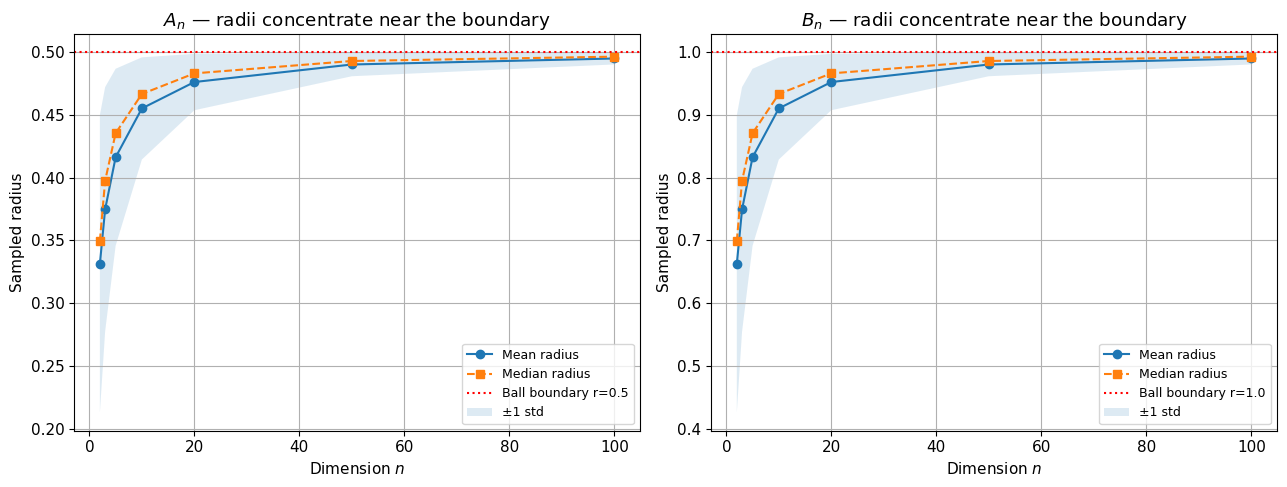

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, shape, radius in zip(axes, ["A","B"], [0.5, 1.0]):
    sub = df_radial[df_radial["shape"]==shape]
    ax.plot(sub["n"], sub["mean_R"],   "o-",  label="Mean radius")
    ax.plot(sub["n"], sub["median_R"], "s--", label="Median radius")
    ax.axhline(radius, color="red", ls=":", label=f"Ball boundary r={radius}")
    ax.fill_between(sub["n"],
                    sub["mean_R"] - sub["std_R"],
                    sub["mean_R"] + sub["std_R"],
                    alpha=0.15, label="±1 std")
    ax.set(title=f"${shape}_n$ — radii concentrate near the boundary",
           xlabel="Dimension $n$", ylabel="Sampled radius")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Final method decision

| Method | Role in this notebook | Keep in report? |
|---|---|---|
| Exact Gamma formula | Ground-truth benchmark | Yes |
| Bounding-box Monte Carlo | Main baseline estimator | Yes |
| Good/bad bounding box test | Explains why sampling region matters | Mention briefly |
| Curse-of-dimensionality plot | Explains n=100 failure | Yes, key figure |
| Repeated Monte Carlo | Confirms zero-hit failure is systematic | Mention briefly |
| Recursive slicing/log-volume | Selected high-dimensional calculation improvement | Yes |
| Direct radial sampling | Shows better valid sampling, not volume estimation | Mention briefly |
| Quasi-Monte Carlo | Better point coverage, still hit-rate limited | Appendix only |

Main conclusion:

Bounding-box Monte Carlo works for 2D and 3D because hit probability is large. It fails for n=100 because hit probability is about 10^-70. Recursive slicing/log-volume is the reliable high-dimensional calculation strategy. Direct radial sampling helps generate valid samples but does not estimate the volume ratio.
